# Aufgabe 0
Im Vorversuch haben wir für einen einfachen ungekoppelten Schwingkreis die Eigenfrequenz bestimmt. Dabei haben wir für den vorgegebenen Kondensator und Spule welche wir auf 1500 Henry eingesteckt haben und eine Anfangsspannung $U_a$ von 10V genutzt. Daraus haben wir eine Eigenfrequenz von $1,813 kHz$ herausbekommen.

# Aufgabe 1


In Aufgabe 1 haben wir die "Tiefpunkt-Schaltung" nachgebaut mit den Bauteilen welche wir auch im Vorversuch verwendet haben und folgenden Schaltkreis aus dem Skript dafür verwendet:
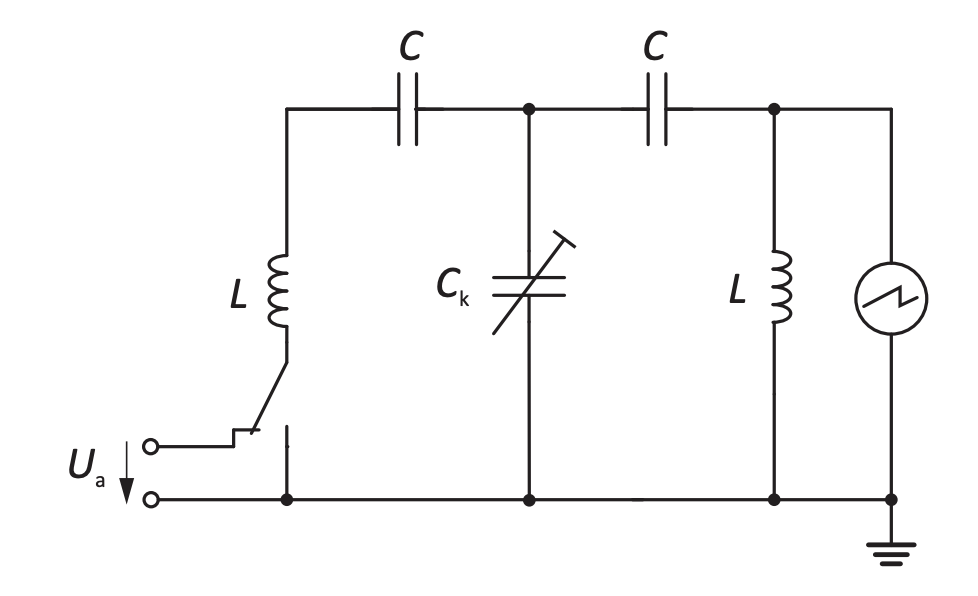

Dann haben wir durch ausprobieren geguckt, in welchem Bereich wir Schwebung beobachten können und somit die gleich- und gegensinnige Schwingung messen können. Da kamen wir auf den Bereich zwischen $10nF$ und $5000nF$, wobei wir für gute Messdaten eine logarithmische Verteilung verwendet haben. Dabei ist uns aufgefallen, dass die Frequenz der gleichsinnigen Schwingung fast immer gleich geblieben ist und nahe $f_0$ war und die gegensinnige Schwingung immer ausgeprägerter wurde und sich immer mehr der gleichsinnigen angenähert hat. Im folgenden sieht man unsere Messungen immer mit der angegebenen Kopplungskapazität in unserem Spektrum welches durch FFT entstanden ist. Jede Messung hatte 2 Peaks, wobei die kleine die gleichsinnige Schwingungsfrequenz ist und die größere die gegensinnige. Währen dem Versuch haben wir außerdem die Frequenzen mithilfe eines Cursors abgelesen und folgende Werte dafür erhalten:

| Kopplungskapazität [nF] | $f_1$ [kHz] |      $f_2$ [kHz] |
| -------------: | -------: | ------------: |
|             15 |    1.807 |         8.082 |
|             20 |    1.825 |         7.187 |
|             35 |    1.807 |         5.453 |
|             50 |    1.825 |         4.792 |
|            100 |    1.825 |         3.765 |
|            200 |    1.812 |         2.895 |
|            350 |    1.812 |         2.447 |
|            500 |    1.812 |         2.281 |
|           1000 |    1.812 |         2.055 |
|           2000 |    1.812 |         1.942 |
|           5000 |    1.812 |         1.841 |


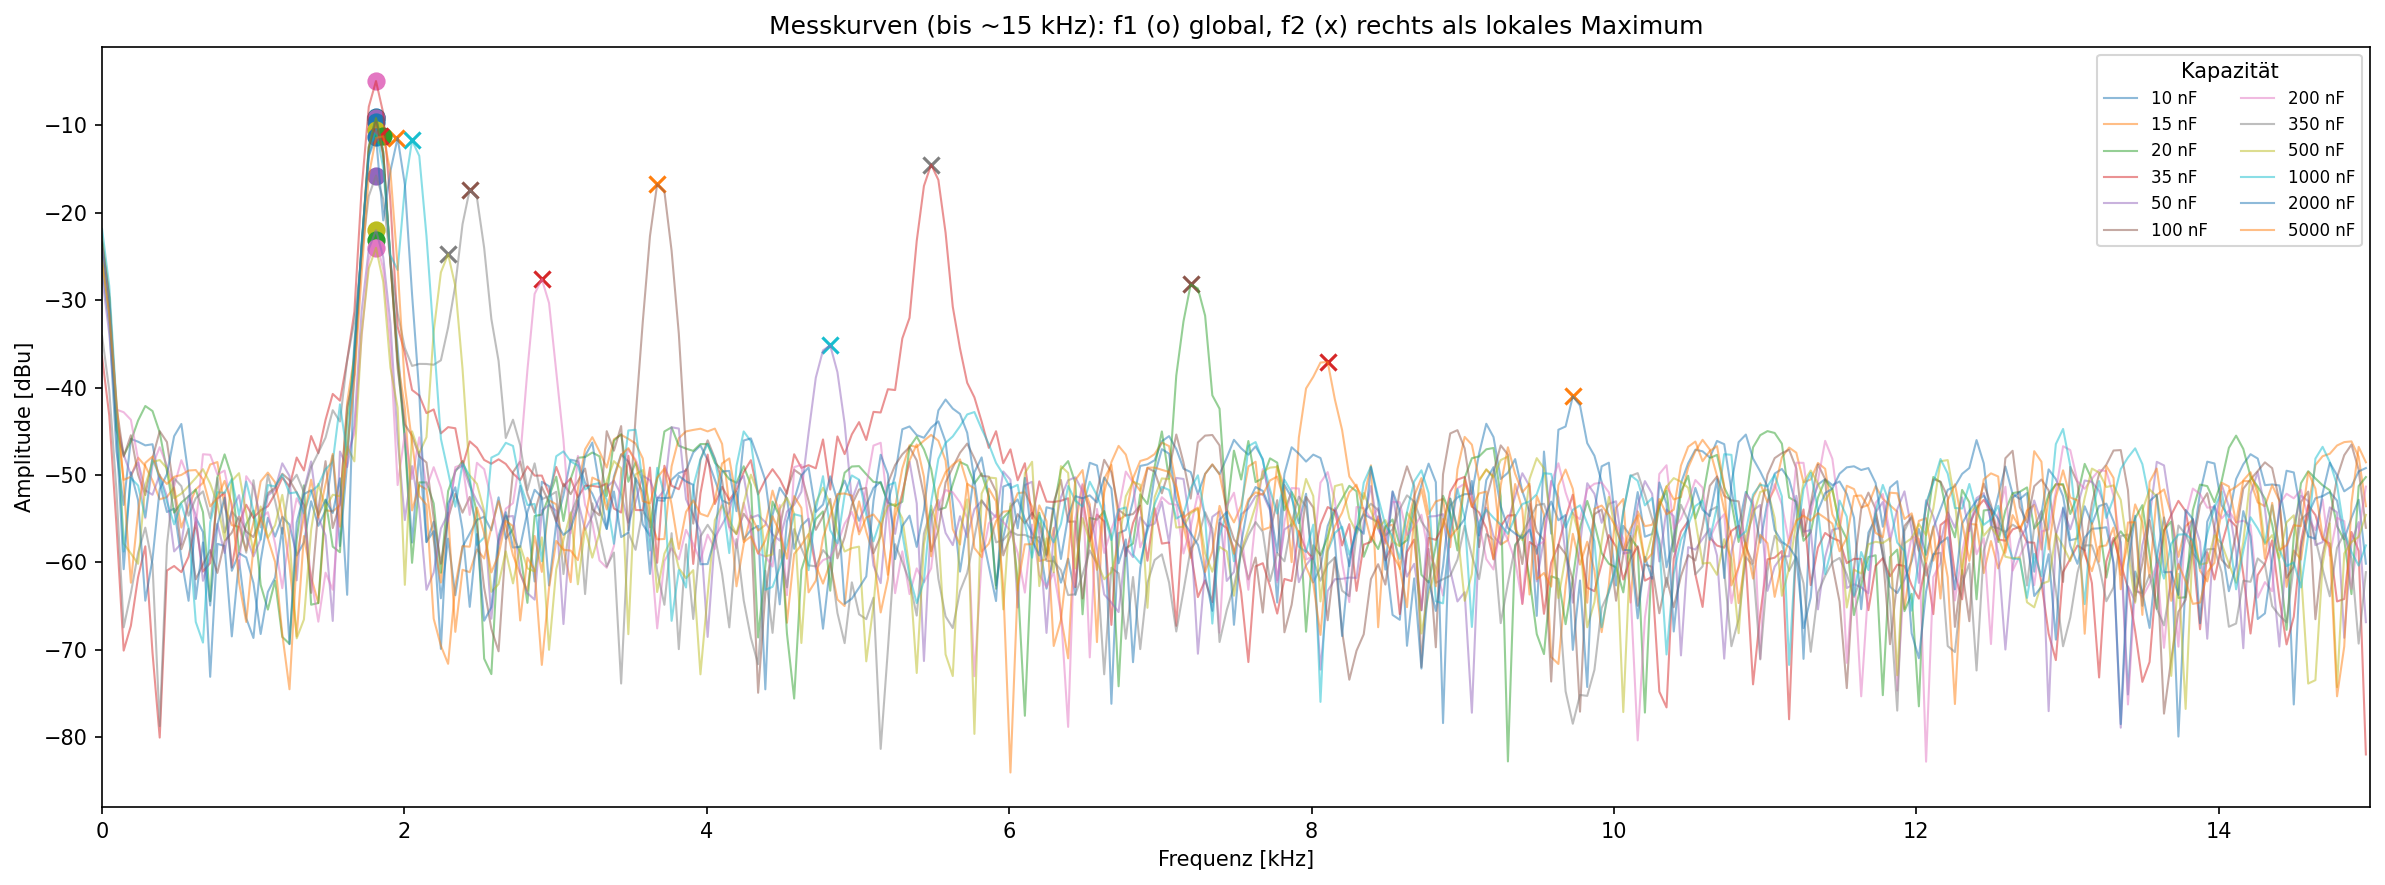


Gefundene Peaks:
 C in nF   f1_kHz   f2_kHz
      10 1.811981 9.727478
      15 1.811981 8.106232
      20 1.811981 7.200241
      35 1.811981 5.483627
      50 1.811981 4.816055
     100 1.811981 3.671646
     200 1.811981 2.908707
     350 1.811981 2.431870
     500 1.811981 2.288818
    1000 1.811981 2.050400
    2000 1.811981 1.940950
    5000 1.859665 1.839871


In [22]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================
# KONFIGURATION
# =========================
DATA_DIR = Path("./Messdaten/Aufgabe1")
ALLOWED_VALUES = [10, 15, 20, 35, 50, 100, 200, 350, 500, 1000, 2000, 5000]

CSV_SEPARATOR_CANDIDIDATES = [",", ";", "\t"]
DECIMAL_CANDIDATES = [".", ","]
ENCODING = "utf-8"

X_COLUMN_NAME = None
Y_COLUMN_NAME = None

X_LIMIT_KHZ = 15.0
FIGSIZE = (16, 6)
DPI = 150

# Heuristiken für f2-Suche
MIN_DROP_DB = 3.0      # Minimum-Abfall nach f1, damit ein Tal zählt
MIN_SEP_KHZ = 0.15     # Mindestabstand f1->f2

# Manuelle f2-Werte für problematische Kapazitäten (kHz)
F2_OVERRIDE_KHZ = {
    2000: 1.94095,
    5000: 1.839871,
}


# =========================
# HELPERS
# =========================
def extract_value_from_filename(stem: str) -> int | None:
    for v in sorted(ALLOWED_VALUES, reverse=True):
        if re.search(rf"(^|[^0-9]){v}([^0-9]|$)", stem):
            return v
    return None

def read_csv_robust(path: Path) -> pd.DataFrame:
    last_err = None
    for sep in CSV_SEPARATOR_CANDIDIDATES:
        for dec in DECIMAL_CANDIDATES:
            try:
                df = pd.read_csv(path, sep=sep, decimal=dec, encoding=ENCODING)
                if df.shape[1] >= 2:
                    return df
            except Exception as e:
                last_err = e
    raise RuntimeError(f"Konnte CSV nicht lesen: {path.name}. Letzter Fehler: {last_err}")

def pick_xy_columns(df: pd.DataFrame) -> tuple[str, str]:
    if X_COLUMN_NAME and Y_COLUMN_NAME:
        if X_COLUMN_NAME not in df.columns or Y_COLUMN_NAME not in df.columns:
            raise ValueError(f"Spalten nicht gefunden. Vorhanden: {list(df.columns)}")
        return X_COLUMN_NAME, Y_COLUMN_NAME

    numeric_cols = []
    for col in df.columns:
        s = pd.to_numeric(df[col], errors="coerce")
        if s.notna().sum() > max(5, int(0.5 * len(s))):
            numeric_cols.append(col)

    if len(numeric_cols) < 2:
        raise ValueError(f"Zu wenige numerische Spalten. Vorhanden: {list(df.columns)}")

    return numeric_cols[0], numeric_cols[1]

def infer_x_units(curves):
    x_max = max(float(np.nanmax(x)) for _, x, _, _ in curves)
    if x_max > 1000:
        return "Hz", 15000.0
    else:
        return "kHz", X_LIMIT_KHZ

def amplitude_at_frequency(xw: np.ndarray, yw: np.ndarray, f: float) -> float:
    """Amplitude am nächsten Datenpunkt zu Frequenz f."""
    idx = int(np.argmin(np.abs(xw - f)))
    return float(yw[idx])

def find_f2_right_local_max(xw: np.ndarray, yw: np.ndarray, i1: int, x_unit: str):
    """
    f2 rechts von f1:
    - warte bis Signal um MIN_DROP_DB gefallen ist (Tal)
    - danach: lokale Maxima sammeln (y[i-1] < y[i] >= y[i+1])
    - nehme das höchste lokale Maximum (robuster gegen Rauschen)
    """
    if i1 >= len(yw) - 3:
        return None, None

    # Mindestabstand in Samples
    dx = np.median(np.diff(xw)) if len(xw) > 5 else 0.01
    if x_unit == "kHz":
        min_sep_samples = int(max(1, MIN_SEP_KHZ / max(dx, 1e-9)))
    else:
        min_sep_samples = int(max(1, (MIN_SEP_KHZ * 1000.0) / max(dx, 1e-9)))

    start = min(len(yw) - 1, i1 + min_sep_samples)

    y1 = yw[i1]
    valley_threshold = y1 - MIN_DROP_DB

    # Tal suchen
    valley_found = False
    valley_start = None
    for i in range(start, len(yw) - 2):
        if yw[i] < valley_threshold:
            valley_found = True
            valley_start = i
            break

    if not valley_found or valley_start is None:
        return None, None

    # lokale Maxima nach Tal
    local_max_idx = []
    for i in range(valley_start + 1, len(yw) - 1):
        if yw[i - 1] < yw[i] >= yw[i + 1]:
            local_max_idx.append(i)

    if not local_max_idx:
        return None, None

    best = max(local_max_idx, key=lambda idx: yw[idx])
    return float(xw[best]), float(yw[best])


# =========================
# MAIN
# =========================
def main():
    csv_files = sorted(DATA_DIR.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"Keine CSV-Dateien in {DATA_DIR.resolve()} gefunden.")

    curves = []
    for path in csv_files:
        C = extract_value_from_filename(path.stem)
        if C is None:
            continue

        df = read_csv_robust(path)
        x_col, y_col = pick_xy_columns(df)

        x = pd.to_numeric(df[x_col], errors="coerce").to_numpy()
        y = pd.to_numeric(df[y_col], errors="coerce").to_numpy()
        m = np.isfinite(x) & np.isfinite(y)
        x, y = x[m], y[m]

        if len(x) < 10:
            continue

        curves.append((C, x, y, path.name))

    if not curves:
        raise RuntimeError("Keine verwertbaren Daten. Prüfe Dateinamen/Spalten/Format.")

    curves.sort(key=lambda t: t[0])

    x_unit, x_limit = infer_x_units(curves)

    plt.figure(figsize=FIGSIZE, dpi=DPI)

    rows = []
    for C, x, y, fname in curves:
        m = (x >= 0) & (x <= x_limit)
        xw, yw = x[m], y[m]
        if len(xw) < 5:
            continue

        plt.plot(xw, yw, linewidth=1, alpha=0.5, label=f"{C} nF")

        # f1 globales Maximum
        i1 = int(np.argmax(yw))
        f1 = float(xw[i1])
        a1 = float(yw[i1])
        plt.scatter([f1], [a1], s=60, marker="o")

        # f2 bestimmen
        f2, a2 = find_f2_right_local_max(xw, yw, i1=i1, x_unit=x_unit)

        # Override für 2000/5000 (nur f2), Marker bleibt normal
        if x_unit == "kHz" and C in F2_OVERRIDE_KHZ:
            f2 = float(F2_OVERRIDE_KHZ[C])
            a2 = amplitude_at_frequency(xw, yw, f2)

        if f2 is not None and a2 is not None:
            plt.scatter([f2], [a2], s=60, marker="x")

        rows.append((C, f1, f2))

    plt.xlim(0, x_limit)
    plt.xlabel(f"Frequenz [{x_unit}]")
    plt.ylabel("Amplitude [dBu]")
    plt.title("Messkurven (bis ~15 kHz): f1 (o) global, f2 (x) rechts als lokales Maximum")
    plt.legend(title="Kapazität", ncols=2, fontsize=8)
    plt.tight_layout()
    plt.show()

    out = pd.DataFrame(rows, columns=["C in nF", f"f1_{x_unit}", f"f2_{x_unit}"])
    print("\nGefundene Peaks:")
    print(out.to_string(index=False))


if __name__ == "__main__":
    main()


Wenn wir die gefundenen Peaks mit den gemessenen vergleichen, stimmen sie sehr gut überein. Deshalb verwenden wir diese aus den Spektren bestimmten Resonanzfrequenzen $f_1$ und $f_2$ für die weitere Auswertung.

## Mathematische Auswertung (Kopplungsgrad und Fit)

Ein System aus zwei gekoppelten (nahezu identischen) Resonatoren besitzt zwei Normalmoden, die sich im Spektrum als zwei Resonanzfrequenzen zeigen. Die Stärke der Kopplung hängt direkt mit der Frequenzaufspaltung zusammen. Aus den beiden Resonanzfrequenzen berechnen wir daher für jede Kapazität $C$ den Kopplungsgrad $k$ über

$$
k(C)=\frac{f_\text{high}(C)^2-f_\text{low}(C)^2}{f_\text{high}(C)^2+f_\text{low}(C)^2},
$$

wobei wir zur eindeutigen Zuordnung

$$
f_\text{low}=\min(f_1,f_2),\qquad f_\text{high}=\max(f_1,f_2)
$$

verwenden. Damit ist sichergestellt, dass stets $f_\text{high}>f_\text{low}$ gilt. Der Kopplungsgrad ist dimensionslos: Liegen beide Resonanzen nahe beieinander, ist $k$ klein (schwache Kopplung). Bei großer Aufspaltung wird $k$ entsprechend größer (starke Kopplung).

Anschließend wird $k$ als Funktion der Kapazität $C$ dargestellt und mit einer geeigneten Fitfunktion beschrieben:

$$
k(C)=\frac{k_0}{1+\left(\frac{C}{C_0}\right)^p}.
$$

Dabei ist $k_0$ der Grenzwert für kleine $C$ (maximale Kopplung im Messbereich), $C_0$ eine charakteristische Kapazität (bei $C=C_0$ gilt $k=k_0/2$), und $p$ beschreibt, wie schnell der Kopplungsgrad mit $C$ abfällt. Dadurch erhalten wir eine glatte Beschreibung des Zusammenhangs $k(C)$ und können die Abhängigkeit der Kopplung von $C$ quantitativ auswerten.

Aus dem folgenden Fit bekommen wir heraus: $k_0 = 0.980093$, $C_0 = 158.188183 nF$ und p = $1.048314$

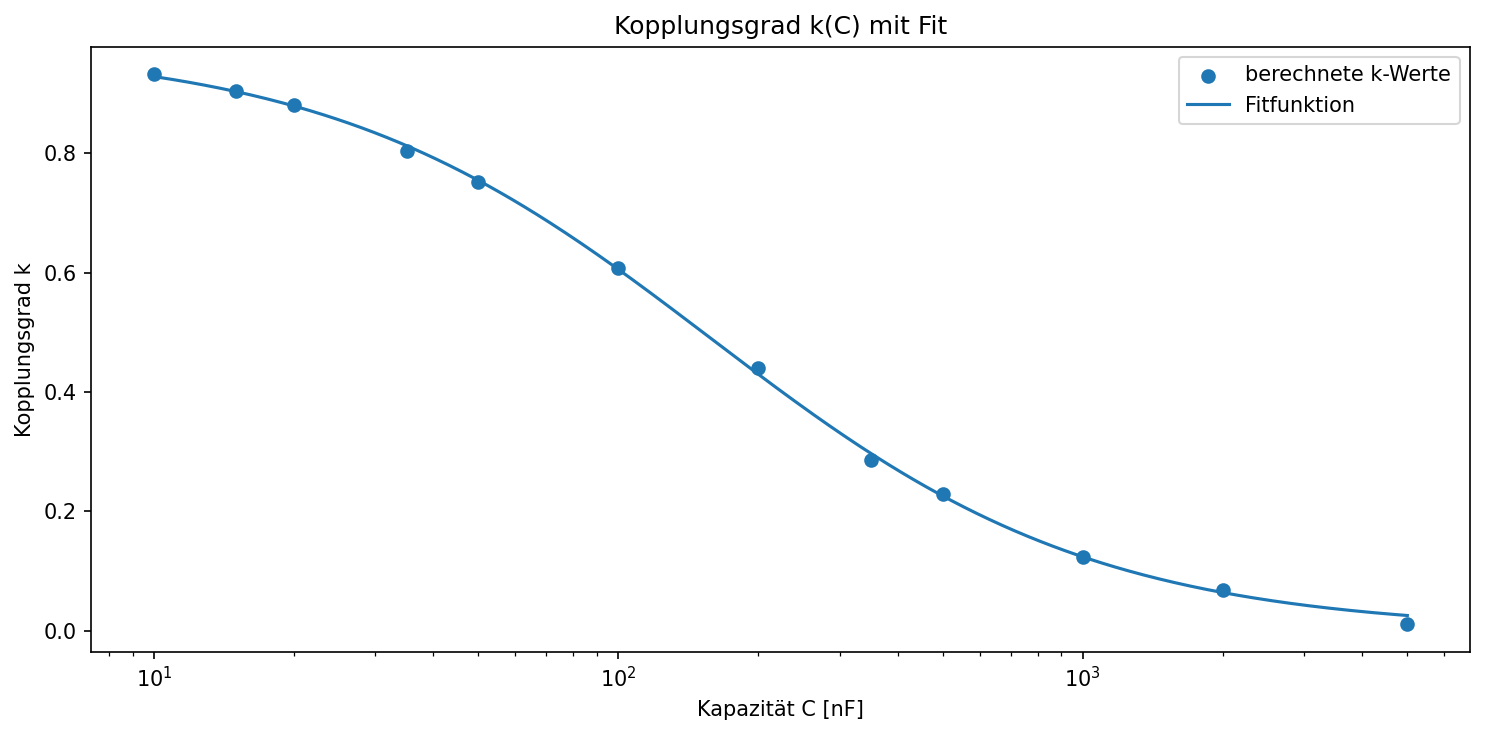


Fitparameter:
k0 = 0.980093
C0 = 158.188183 nF
p  = 1.048314


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit


# =========================
# 1) DATEN (deine Peaks)
# =========================
data = [
    # C_nF, f1_kHz, f2_kHz
    (10,   1.811981, 9.727478),
    (15,   1.811981, 8.106232),
    (20,   1.811981, 7.200241),
    (35,   1.811981, 5.483627),
    (50,   1.811981, 4.816055),
    (100,  1.811981, 3.671646),
    (200,  1.811981, 2.908707),
    (350,  1.811981, 2.431870),
    (500,  1.811981, 2.288818),
    (1000, 1.811981, 2.050400),
    (2000, 1.811981, 1.940950),
    (5000, 1.859665, 1.839871),
]

df = pd.DataFrame(data, columns=["C_nF", "f1_kHz", "f2_kHz"])


# =========================
# 2) KOPPLUNGSGRAD
#    robust: sortiere Frequenzen pro Zeile
# =========================
f_low = np.minimum(df["f1_kHz"].to_numpy(float), df["f2_kHz"].to_numpy(float))
f_high = np.maximum(df["f1_kHz"].to_numpy(float), df["f2_kHz"].to_numpy(float))

k = (f_high**2 - f_low**2) / (f_high**2 + f_low**2)
df["f_low_kHz"] = f_low
df["f_high_kHz"] = f_high
df["k"] = k


# =========================
# 3) FIT: k(C) = k0 / (1 + (C/C0)^p)
# =========================
def k_model(C, k0, C0, p):
    return k0 / (1.0 + (C / C0) ** p)

def r2_score(y, yhat):
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

C = df["C_nF"].to_numpy(float)
y = df["k"].to_numpy(float)

p0 = [float(np.max(y)), 200.0, 1.0]
bounds = ([0.0, 1e-9, 0.0], [1.0, np.inf, 10.0])

popt, pcov = curve_fit(k_model, C, y, p0=p0, bounds=bounds, maxfev=20000)
k0, C0, p = popt

y_hat = k_model(C, *popt)
r2 = r2_score(y, y_hat)

C_plot = np.logspace(np.log10(C.min()), np.log10(C.max()), 400)
k_plot = k_model(C_plot, *popt)


# =========================
# 4) PLOT
# =========================
plt.figure(figsize=(10, 5), dpi=150)
plt.scatter(C, y, label="berechnete k-Werte")
plt.plot(C_plot, k_plot, label=f"Fitfunktion")
plt.xscale("log")
plt.xlabel("Kapazität C [nF]")
plt.ylabel("Kopplungsgrad k")
plt.title("Kopplungsgrad k(C) mit Fit")
plt.legend()
plt.tight_layout()
plt.show()


print("\nFitparameter:")
print(f"k0 = {k0:.6f}")
print(f"C0 = {C0:.6f} nF")
print(f"p  = {p:.6f}")
